# Step 5 - Spatial Neighborhood Analysis
How do clusters interact spatially inside the tumor?

## Load data:

In [1]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import matplotlib.pyplot as plt

adata = sc.read_h5ad(
    "../data/processed/breast_cancer_visium_clustered.h5ad"
)

adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'leiden_0_5', 'leiden_0_2', 'leiden_0_4', 'leiden_0_6', 'leiden_0_8', 'leiden_1_0'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'leiden_0_2', 'leiden_0_2_colors', 'leiden_0_4', 'leiden_0_4_colors', 'leiden_0_5', 'leiden_0_5_colors', 'leiden_0_6', 'leiden_0_6_colors', 'leiden_0_8', 'leiden_0_8_colors', 'leiden_1_0', 'leiden_1_0_colors', 'log1p', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distance

# Build Spatial Graph
Earlier I've built Expression similarity. Now I am about to build Physical proximity on tissue.

## Build graph:

In [2]:
sq.gr.spatial_neighbors(adata)
adata.obsp.keys()

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


KeysView(PairwiseArrays with keys: connectivities, distances, spatial_connectivities, spatial_distances)

## Visualize Spatial Graph

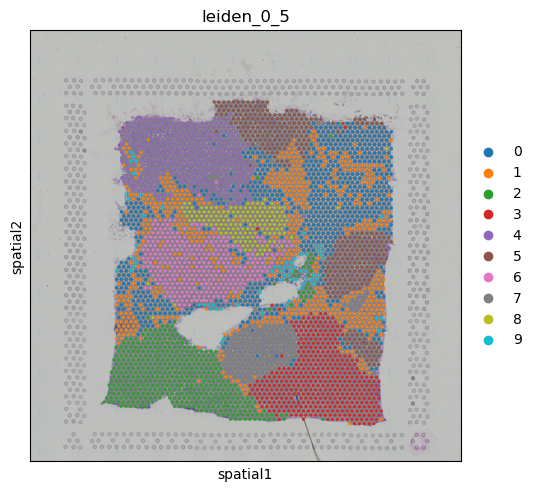

In [3]:
sq.pl.spatial_scatter(
    adata,
    color="leiden_0_5",
    connectivity_key="spatial_connectivities"
)

## Neighborhood Enrichment

In [4]:
sq.gr.nhood_enrichment(
    adata,
    cluster_key="leiden_0_5"
)

  0%|          | 0/1000 [00:00<?, ?/s]

and plot

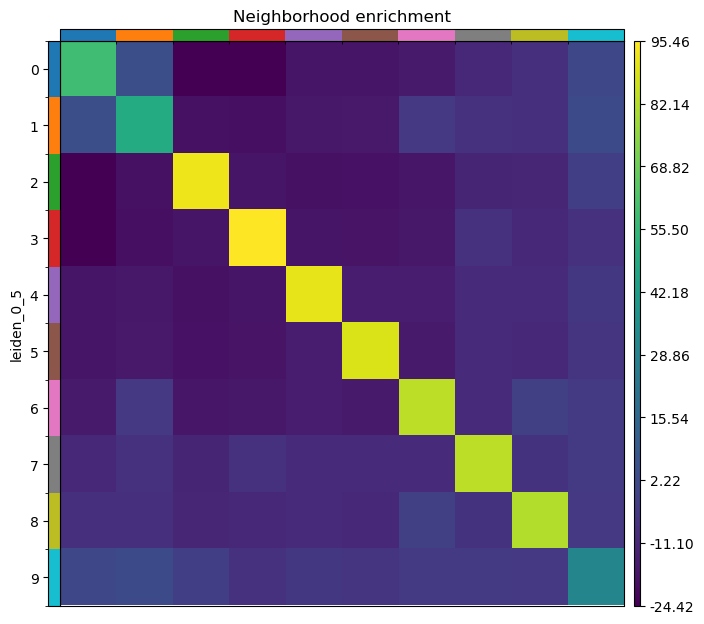

In [5]:
sq.pl.nhood_enrichment(
    adata,
    cluster_key="leiden_0_5"
)

## Interpretation

Observed neighboring interactions vs Random neighboring interactions

- Positive (yellow/green): Clusters are neighbors MORE often than expected
- Negative (purple): Clusters are neighbors LESS often than expected

### First Observation: The diagonal is extremely bright.
=> Strong self-enrichment along the diagonal indicates that transcriptionally defined clusters occupy spatially coherent tissue regions.

### Second Observation: Cluster 2 forms a highly localized spatial domain

Possible biological explanations:

- tumor nest
- immune aggregate
- stromal compartment

=> Marker genes will tell.


### Third Observation: Most off-diagonal values are negative.
=> Most clusters exhibit spatial segregation.


### Fourth Observation: Cluster 9 is positive but much weaker than clusters 2,3,4,5
=> Cluster 9 may be more dispersed across tissue.
Potentially:

- transition zone
- mixed tissue
- low-confidence cluster

### Interpretation

Neighborhood enrichment analysis revealed strong self-enrichment across all Leiden clusters, indicating that the identified transcriptional clusters form spatially coherent tissue regions.

Most off-diagonal interactions exhibited negative enrichment, suggesting substantial spatial segregation between clusters.

Clusters 2, 3, 4, and 5 displayed particularly strong self-enrichment, indicating highly localized spatial domains. In contrast, cluster 9 exhibited weaker self-enrichment, suggesting a more dispersed spatial distribution.

These findings indicate that the breast cancer tissue contains multiple distinct transcriptional niches whose biological identities will be investigated through marker gene analysis.

## Co-occurrence

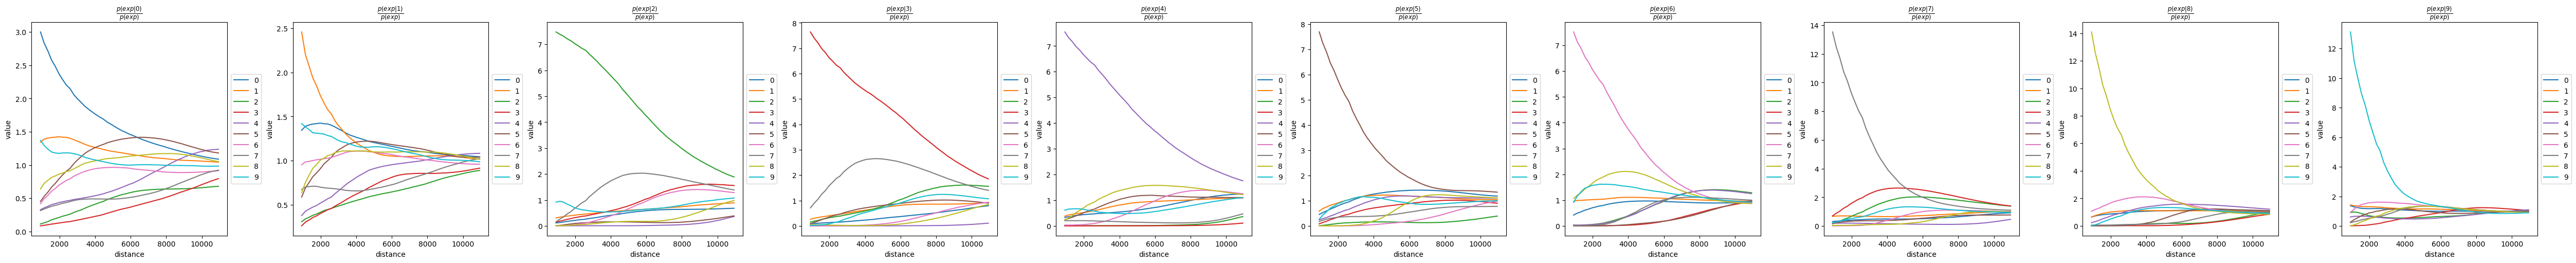

In [6]:
# compute
sq.gr.co_occurrence(
    adata,
    cluster_key="leiden_0_5"
)

# then plot
sq.pl.co_occurrence(
    adata,
    cluster_key="leiden_0_5"
)

## Centrality Analysis

In [ ]:
# Find influential spatial regions.
sq.gr.centrality_scores(
    adata,
    cluster_key="leiden_0_5"
)

# plot
sq.pl.centrality_scores(
    adata,
    cluster_key="leiden_0_5"
)

# Which cluster acts as a spatial hub?

## Save Results

In [ ]:
adata.write(
    "../data/processed/breast_cancer_spatial_analysis.h5ad"
)